# Retail Decision Intelligence
## Hierarchical demand forecasting, latent-demand recovery, stockout prediction, product substitution, promotion evaluation, and inventory optimisation
 
**Author:** Mark I. R. Petalcorin  
**Prepared:** July 2026

This notebook builds a reproducible, end-to-end retail analytics workflow using a fully synthetic dataset. It is designed around commercially relevant grocery problems: product-store forecasting, stock availability, online substitutions, promotion response, uncertainty, explainability, and operational decision optimisation.

> **Important:** All transactions are simulated. Published studies are used only to benchmark broad characteristics and parameter ranges. The notebook does not reproduce or claim access to proprietary data.

## Executive questions

1. Can a global machine-learning model outperform a seasonal-naive forecast across many product-store series?
2. How much demand is hidden when observed sales are censored by stockouts?
3. Can stockout risk be identified early enough to support replenishment intervention?
4. Can an attribute-aware model select more acceptable substitutes than simple price matching?
5. Can promotion effects be separated from seasonality and store differences?
6. Do probabilistic forecasts improve service level and reduce decision cost?
7. Which factors drive predictions, and where does performance vary by store segment?

## Peer-reviewed evidence used to benchmark the simulation

| Evidence | Published finding used | Notebook mapping |
|---|---:|---|
| Makridakis, Spiliotis, and Assimakopoulos, *International Journal of Forecasting* (2022), DOI: https://doi.org/10.1016/j.ijforecast.2021.11.013 | M5 evaluated 42,840 hierarchical retail series; top solutions used global ML models, especially LightGBM | Multiple stores, categories and SKUs; global LightGBM model; bottom-up aggregation |
| Ziel, *International Journal of Forecasting* (2022), DOI: https://doi.org/10.1016/j.ijforecast.2021.09.008 | Retail counts are overdispersed, sporadic, and often zero | Zero-inflated negative-binomial demand generation and quantile forecasts |
| Fildes et al., *International Journal of Forecasting* (2022), PMID: 36217499, DOI: https://doi.org/10.1016/j.ijforecast.2021.09.012 | Retail forecasting must handle structural change, disruption, ML and omni-retailing | Promotions, campaigns, holidays, weather, disruptions and time-based validation |
| Powell et al., *Preventive Medicine* (2016), PMID: 26827618, DOI: https://doi.org/10.1016/j.ypmed.2016.01.011 | Supermarket promotions averaged 13.4%; promoted prices were about 15.2% lower | Promotion probability = 0.134; mean discount ≈ 0.152 |
| Rosin et al., *Nutrition & Dietetics* (2023), PMID: 36843241, DOI: https://doi.org/10.1111/1747-0080.12800 | Supermarket promotions produced roughly 2–2.5-fold sales | Promotion multiplier sampled around 1.65–2.35 |
| Trewern et al., *Public Health Nutrition* (2022), PMID: 36073024, DOI: https://doi.org/10.1017/S1368980022001914 | A UK supermarket plant-based campaign increased weekly sales by about 57% | January plant-based campaign multiplier = 1.57 |
| Vasconcellos and Sampaio, *Brazilian Administration Review* (2009), DOI: https://doi.org/10.1590/S1807-76922009000300007 | Historical supermarket stockout estimates commonly averaged above 8% | Inventory-capacity calibration targets an approximately 8–10% stockout rate |
| Anupindi, Dada, and Gupta, *Marketing Science* (1998), DOI: https://doi.org/10.1287/mksc.17.4.406 | Stockouts censor focal demand and inflate substitute sales | Separate latent demand, observed sales, lost sales, and substitution events |
| Hoang and Breugelmans, *Journal of Retailing* (2023), DOI: https://doi.org/10.1016/j.jretai.2022.06.006 | Attribute- and purchase-history-matched substitutions improve acceptance | Candidate-ranking features include price, size, tier, health score, affinity and past purchase |
| Luick et al., *BMC Public Health* (2024), PMID: 38907224, DOI: https://doi.org/10.1186/s12889-024-19080-x | Store-level promotion effects vary by product and socioeconomic context | Store affluence and format are retained for heterogeneous-effect diagnostics |

**Scenario assumption:** the absolute probability of accepting a substitute is not fixed to a single literature value because the cited studies establish strong policy and attribute effects but do not provide one universal acceptance rate. The notebook therefore simulates this probability transparently and tests sensitivity through predictive evaluation.

In [4]:
# Core imports and reproducibility
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from scipy.special import expit, softmax
from scipy.stats import bootstrap

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMRegressor, LGBMClassifier
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')
SEED = 42
rng = np.random.default_rng(SEED)

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
plt.rcParams.update({
    'figure.figsize': (10, 5.5),
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'figure.dpi': 120,
})

OUTPUT_DIR = Path('retail_ai_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
print(f'Outputs will be written to: {OUTPUT_DIR.resolve()}')

Outputs will be written to: /Users/petalc01/retail-decision-intelligence/retail_ai_outputs


## 1. Simulation design

The synthetic panel contains daily product-store observations. Latent customer demand is generated before inventory constraints. Observed sales are then the minimum of latent demand and available stock. This preserves the key distinction between **what customers wanted** and **what the retailer was able to sell**.

In [9]:
# Configuration
N_STORES = 4
N_PRODUCTS = 18
N_DAYS = 540
DATES = pd.date_range('2024-01-01', periods=N_DAYS, freq='D')

stores = pd.DataFrame({
    'store_id': [f'S{i+1:02d}' for i in range(N_STORES)],
    'store_format': ['superstore', 'superstore', 'convenience', 'urban'],
    'affluence_index': [0.25, 0.65, 0.40, 0.80],
    'footfall_index': [1.35, 1.15, 0.72, 0.95],
})

categories = ['Fresh', 'Dairy', 'Bakery', 'Plant-based', 'Household', 'Beverages']
base_category_demand = {
    'Fresh': 18, 'Dairy': 22, 'Bakery': 14,
    'Plant-based': 8, 'Household': 6, 'Beverages': 16,
}

products = []
for j in range(N_PRODUCTS):
    category = categories[j % len(categories)]
    products.append({
        'product_id': f'P{j+1:03d}',
        'category': category,
        'brand_id': f'B{(j % 8) + 1:02d}',
        'brand_tier': ['value', 'standard', 'premium'][j % 3],
        'base_price': round(rng.uniform(1.10, 7.50), 2),
        'unit_cost_ratio': rng.uniform(0.48, 0.72),
        'base_demand': base_category_demand[category] * rng.lognormal(0, 0.32),
        'perishable': int(category in ['Fresh', 'Dairy', 'Bakery', 'Plant-based']),
        'health_score': rng.uniform(1, 5),
        'size_index': rng.uniform(0.75, 1.35),
        'price_elasticity': -rng.uniform(0.8, 2.4),
    })
products = pd.DataFrame(products)

display(stores)
display(products.head())

,store_id,store_format,affluence_index,footfall_index
0,S01,superstore,0.250,1.350
1,S02,superstore,0.650,1.150
2,S03,convenience,0.400,0.720
3,S04,urban,0.800,0.950


,product_id,category,brand_id,brand_tier,base_price,unit_cost_ratio,base_demand,perishable,health_score,size_index,price_elasticity
0,P001,Fresh,B01,value,6.050,0.585,22.886,1,3.789,0.807,-2.361
1,P002,Dairy,B02,standard,5.970,0.669,21.882,1,2.802,0.972,-2.283
2,P003,Bakery,B03,premium,5.220,0.677,16.259,1,1.909,1.083,-0.902
3,P004,Plant-based,B04,value,6.400,0.632,7.540,1,2.418,1.332,-2.229
4,P005,Household,B05,standard,6.080,0.527,7.114,0,1.175,0.843,-1.893


In [11]:
def simulate_retail_panel(stores, products, dates, seed=42):
    local_rng = np.random.default_rng(seed)
    rows = []

    for store in stores.itertuples(index=False):
        for product in products.itertuples(index=False):
            local_base = product.base_demand * store.footfall_index * local_rng.lognormal(0, 0.12)
            phase = local_rng.uniform(0, 2 * np.pi)

            for day_index, date in enumerate(dates):
                dow = date.dayofweek
                weekend = int(dow >= 5)
                weekly = 1 + 0.16 * np.sin(2 * np.pi * dow / 7 + phase) + 0.10 * weekend
                annual = 1 + 0.11 * np.sin(2 * np.pi * day_index / 365 + phase / 2)
                trend = 1 + 0.00018 * day_index

                holiday = int((date.month == 12 and date.day >= 15) or (date.month == 4 and date.day <= 7))
                holiday_multiplier = 1.25 if product.category in ['Fresh', 'Beverages', 'Bakery'] else 1.10

                promotion = int(local_rng.random() < 0.134)
                discount = np.clip(local_rng.normal(0.152, 0.055), 0.05, 0.35) if promotion else 0.0
                price = product.base_price * (1 - discount)
                promotion_multiplier = local_rng.uniform(1.65, 2.35) if promotion else 1.0

                campaign = int(product.category == 'Plant-based' and date.month == 1)
                campaign_multiplier = 1.57 if campaign else 1.0

                temperature = local_rng.normal(10 + 7 * np.sin(2 * np.pi * (day_index - 170) / 365), 3)
                weather_multiplier = (
                    1 + 0.012 * max(temperature - 18, 0)
                    if product.category == 'Beverages' else 1.0
                )

                expected_demand = (
                    local_base * weekly * annual * trend
                    * (holiday_multiplier if holiday else 1.0)
                    * promotion_multiplier * campaign_multiplier * weather_multiplier
                )

                zero_probability = np.clip(0.38 - np.log1p(local_base) / 10, 0.02, 0.35)
                if local_rng.random() < zero_probability:
                    latent_demand = 0
                else:
                    dispersion = 5.0
                    probability = dispersion / (dispersion + max(expected_demand, 1e-6))
                    latent_demand = local_rng.negative_binomial(dispersion, probability)

                normal_capacity = max(1, local_rng.poisson(max(expected_demand * 1.85, 1)))
                disruption = local_rng.random() < (
                    0.018 + 0.010 * product.perishable + 0.008 * promotion
                )
                if disruption:
                    normal_capacity = max(0, int(normal_capacity * local_rng.uniform(0.15, 0.55)))

                observed_sales = min(latent_demand, normal_capacity)
                stockout = int(latent_demand > normal_capacity)
                lost_sales = latent_demand - observed_sales

                rows.append({
                    'date': date,
                    'store_id': store.store_id,
                    'store_format': store.store_format,
                    'affluence_index': store.affluence_index,
                    'product_id': product.product_id,
                    'category': product.category,
                    'brand_id': product.brand_id,
                    'brand_tier': product.brand_tier,
                    'perishable': product.perishable,
                    'health_score': product.health_score,
                    'size_index': product.size_index,
                    'regular_price': product.base_price,
                    'price': price,
                    'unit_cost': product.base_price * product.unit_cost_ratio,
                    'price_elasticity': product.price_elasticity,
                    'promo': promotion,
                    'discount': discount,
                    'campaign': campaign,
                    'holiday': holiday,
                    'temperature_c': temperature,
                    'expected_demand': expected_demand,
                    'latent_demand': latent_demand,
                    'available_stock': normal_capacity,
                    'units_sold': observed_sales,
                    'stockout': stockout,
                    'lost_sales': lost_sales,
                })

    return pd.DataFrame(rows)

retail = simulate_retail_panel(stores, products, DATES, seed=SEED)
retail = retail.sort_values(['store_id', 'product_id', 'date']).reset_index(drop=True)
print(retail.shape)
display(retail.head())

(38880, 26)


,date,store_id,store_format,affluence_index,product_id,category,brand_id,brand_tier,perishable,health_score,size_index,regular_price,price,unit_cost,price_elasticity,promo,discount,campaign,holiday,temperature_c,expected_demand,latent_demand,available_stock,units_sold,stockout,lost_sales
0,2024-01-01,S01,superstore,0.250,P001,Fresh,B01,value,1,3.789,0.807,6.050,6.050,3.541,-2.361,0,0.000,0,0,11.327,37.635,22,68,22,0,0
1,2024-01-02,S01,superstore,0.250,P001,Fresh,B01,value,1,3.789,0.807,6.050,6.050,3.541,-2.361,0,0.000,0,0,11.770,32.732,22,72,22,0,0
2,2024-01-03,S01,superstore,0.250,P001,Fresh,B01,value,1,3.789,0.807,6.050,6.050,3.541,-2.361,0,0.000,0,0,9.367,29.926,51,52,51,0,0
3,2024-01-04,S01,superstore,0.250,P001,Fresh,B01,value,1,3.789,0.807,6.050,5.410,3.541,-2.361,1,0.106,0,0,10.106,56.702,75,98,75,0,0
4,2024-01-05,S01,superstore,0.250,P001,Fresh,B01,value,1,3.789,0.807,6.050,6.050,3.541,-2.361,0,0.000,0,0,8.241,35.939,50,68,50,0,0


In [4]:
# Benchmark audit
benchmark_audit = pd.DataFrame({
    'Measure': [
        'Rows', 'Product-store series', 'Promotion prevalence',
        'Mean promotional discount', 'Stockout rate', 'Zero-sales rate',
        'Mean latent demand', 'Mean observed sales', 'Demand censoring bias'
    ],
    'Value': [
        len(retail),
        retail[['store_id', 'product_id']].drop_duplicates().shape[0],
        retail['promo'].mean(),
        retail.loc[retail['promo'].eq(1), 'discount'].mean(),
        retail['stockout'].mean(),
        retail['units_sold'].eq(0).mean(),
        retail['latent_demand'].mean(),
        retail['units_sold'].mean(),
        retail['units_sold'].mean() - retail['latent_demand'].mean(),
    ]
})
display(benchmark_audit)

assert 0.11 < retail['promo'].mean() < 0.16
assert 0.12 < retail.loc[retail['promo'].eq(1), 'discount'].mean() < 0.19
assert 0.06 < retail['stockout'].mean() < 0.13
assert (retail['units_sold'] <= retail['latent_demand']).all()

,Measure,Value
0,Rows,"38,880.000"
1,Product-store series,72.000
2,Promotion prevalence,0.138
3,Mean promotional discount,0.152
4,Stockout rate,0.092
5,Zero-sales rate,0.133
6,Mean latent demand,16.056
7,Mean observed sales,15.401
8,Demand censoring bias,-0.656


### Interpretation

The audit verifies that the synthetic panel is close to the intended evidence-based ranges. Stockouts create a systematic downward gap between observed sales and latent demand, so a model trained naively on sales can learn an operationally biased target.

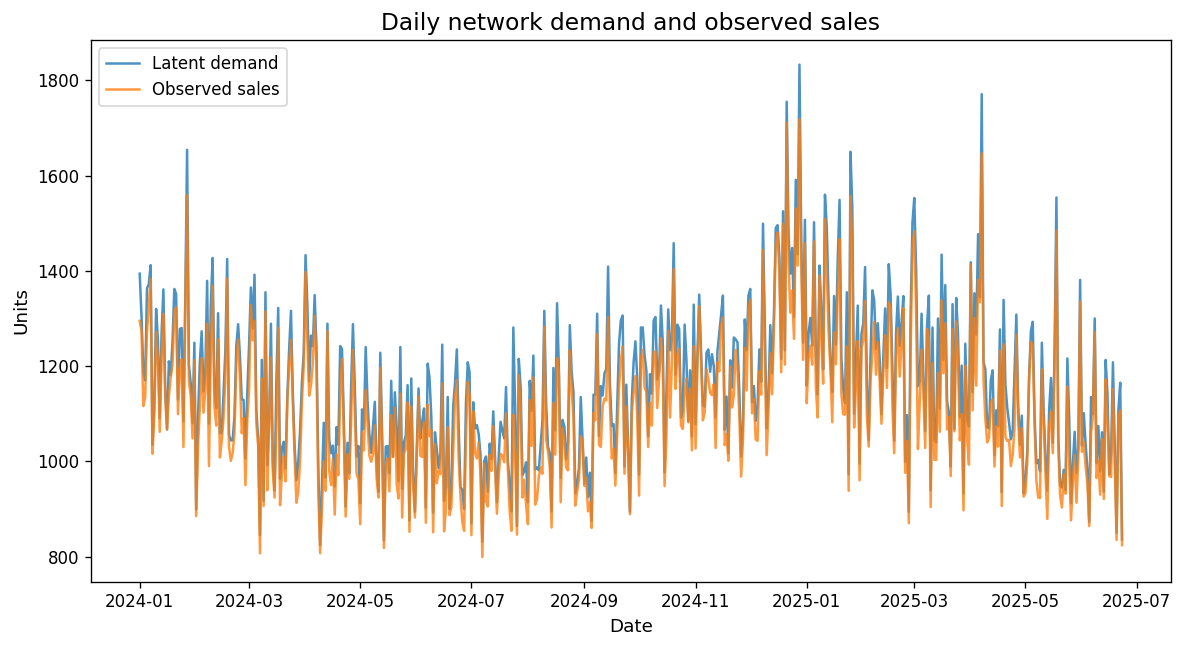

In [5]:
# Visual 1: total daily observed and latent demand
trend = retail.groupby('date', as_index=False)[['units_sold', 'latent_demand']].sum()
plt.figure()
plt.plot(trend['date'], trend['latent_demand'], label='Latent demand', alpha=0.8)
plt.plot(trend['date'], trend['units_sold'], label='Observed sales', alpha=0.8)
plt.title('Daily network demand and observed sales')
plt.xlabel('Date')
plt.ylabel('Units')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_daily_demand.png', bbox_inches='tight')
plt.show()

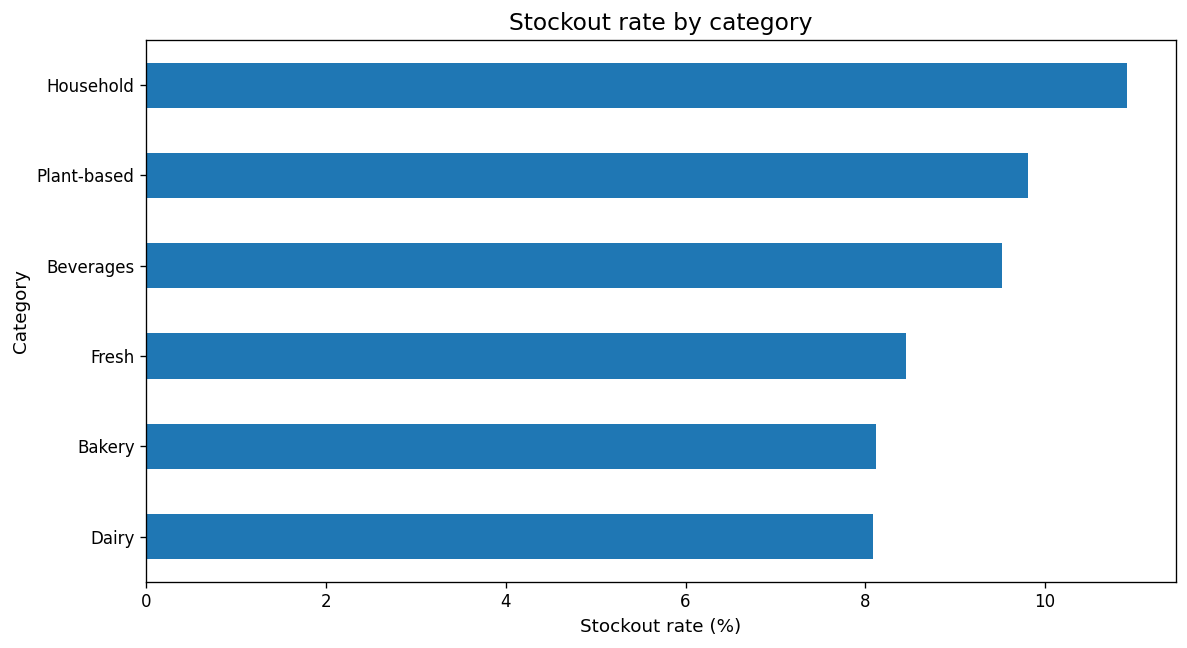

In [6]:
# Visual 2: stockout rate by category
category_stockout = retail.groupby('category')['stockout'].mean().sort_values()
plt.figure()
category_stockout.mul(100).plot(kind='barh')
plt.title('Stockout rate by category')
plt.xlabel('Stockout rate (%)')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_stockout_by_category.png', bbox_inches='tight')
plt.show()

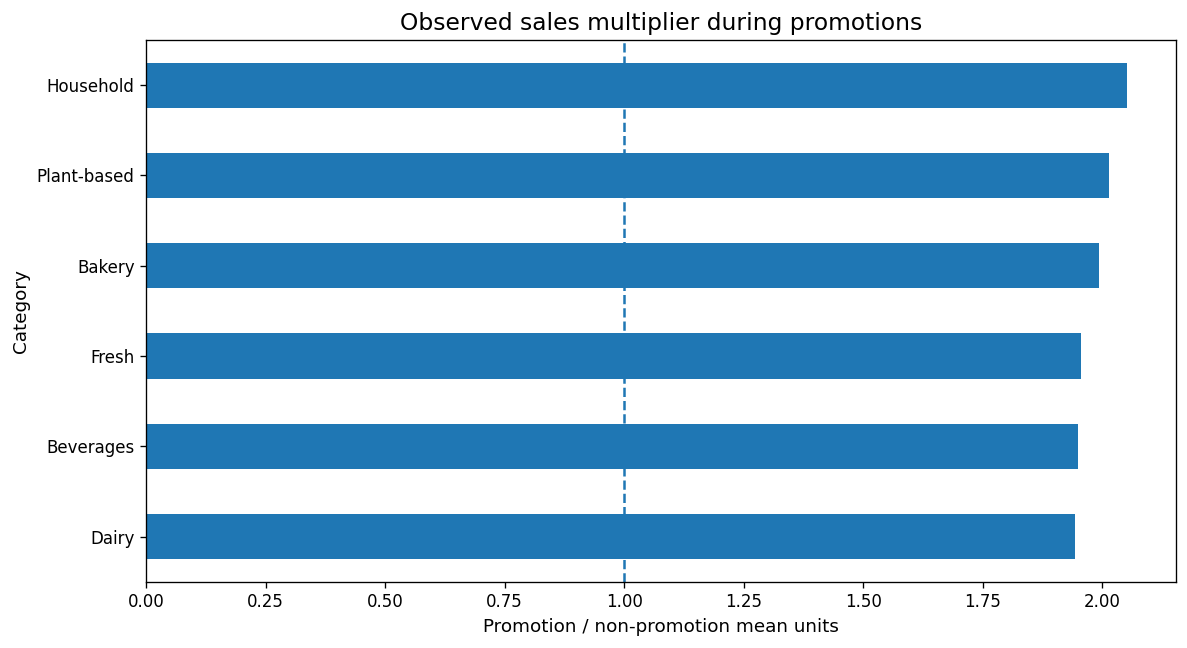

promo,No promotion,Promotion,Observed multiplier
category,,,
Bakery,14.692,29.272,1.992
Beverages,13.739,26.792,1.950
Dairy,23.602,45.877,1.944
Fresh,17.351,33.947,1.956
Household,3.772,7.739,2.052
Plant-based,8.418,16.950,2.014


In [7]:
# Visual 3: observed promotion lift by category
promo_summary = (
    retail.groupby(['category', 'promo'])['units_sold']
    .mean().unstack()
    .rename(columns={0: 'No promotion', 1: 'Promotion'})
)
promo_summary['Observed multiplier'] = promo_summary['Promotion'] / promo_summary['No promotion']
plt.figure()
promo_summary['Observed multiplier'].sort_values().plot(kind='barh')
plt.axvline(1.0, linestyle='--')
plt.title('Observed sales multiplier during promotions')
plt.xlabel('Promotion / non-promotion mean units')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_promotion_multiplier.png', bbox_inches='tight')
plt.show()
display(promo_summary)

## 2. Leakage-safe feature engineering

All lag and rolling features are shifted, so each row uses only information available before the target day. The final 56 days are held out chronologically. This is a stricter and more realistic validation design than a random train-test split.

In [8]:
def add_time_series_features(frame):
    df = frame.copy().sort_values(['store_id', 'product_id', 'date']).reset_index(drop=True)
    group_keys = ['store_id', 'product_id']

    for lag in [1, 7, 14, 28]:
        df[f'lag_{lag}'] = df.groupby(group_keys)['units_sold'].shift(lag)

    for window in [7, 28]:
        df[f'roll_mean_{window}'] = df.groupby(group_keys)['units_sold'].transform(
            lambda s: s.shift(1).rolling(window, min_periods=3).mean()
        )
        df[f'roll_std_{window}'] = df.groupby(group_keys)['units_sold'].transform(
            lambda s: s.shift(1).rolling(window, min_periods=3).std()
        )

    df['dow'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
    df['day_sin'] = np.sin(2 * np.pi * df['dow'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['dow'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    for col in ['store_id', 'store_format', 'product_id', 'category', 'brand_id', 'brand_tier']:
        df[f'{col}_code'] = df[col].astype('category').cat.codes

    expected_proxy = df['roll_mean_28'].fillna(df['units_sold'])
    stockout_proxy = np.maximum.reduce([
        df['units_sold'].to_numpy(),
        (1.15 * expected_proxy).to_numpy(),
        (df['available_stock'] + 0.5 * df['roll_std_28'].fillna(0)).to_numpy(),
    ])
    df['demand_proxy'] = np.where(df['stockout'].eq(1), stockout_proxy, df['units_sold'])
    return df

model_data = add_time_series_features(retail)
model_data = model_data.dropna(subset=['lag_28', 'roll_mean_28', 'roll_std_28']).copy()

cutoff = DATES[-56]
train = model_data.loc[model_data['date'] < cutoff].copy()
test = model_data.loc[model_data['date'] >= cutoff].copy()

FEATURES = [
    'regular_price', 'price', 'discount', 'promo', 'campaign', 'holiday',
    'temperature_c', 'affluence_index', 'perishable', 'health_score', 'size_index',
    'dow', 'month', 'weekofyear', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
    'store_id_code', 'store_format_code', 'product_id_code', 'category_code',
    'brand_id_code', 'brand_tier_code',
    'lag_1', 'lag_7', 'lag_14', 'lag_28',
    'roll_mean_7', 'roll_mean_28', 'roll_std_7', 'roll_std_28',
]

print(f'Train: {train.date.min().date()} to {train.date.max().date()}, n={len(train):,}')
print(f'Test:  {test.date.min().date()} to {test.date.max().date()}, n={len(test):,}')

Train: 2024-01-29 to 2025-04-28, n=32,832
Test:  2025-04-29 to 2025-06-23, n=4,032


## 3. Global demand forecasting

Three approaches are compared:

- **Seasonal naive:** use sales from the same weekday one week earlier.
- **Observed-sales LightGBM:** learn directly from sales, including censored stockout days.
- **Demand-corrected LightGBM:** replace stockout-day targets with a transparent proxy based on recent demand, available stock and variability.

The simulated latent demand is used **only for evaluation**, allowing us to measure the hidden bias caused by sales censoring.

In [9]:
def regression_metrics(y_true, y_pred, name):
    y_true = np.asarray(y_true)
    y_pred = np.clip(np.asarray(y_pred), 0, None)
    return {
        'Model': name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'WAPE': np.abs(y_true - y_pred).sum() / max(y_true.sum(), 1),
        'Bias': np.mean(y_pred - y_true),
        'RMSLE': np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)),
    }

lgb_params = dict(
    n_estimators=120,
    learning_rate=0.05,
    num_leaves=24,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=SEED,
    verbosity=-1,
    n_jobs=1,
)

observed_model = LGBMRegressor(objective='regression_l1', **lgb_params)
observed_model.fit(train[FEATURES], train['units_sold'])

corrected_model = LGBMRegressor(objective='regression_l1', **lgb_params)
corrected_model.fit(train[FEATURES], train['demand_proxy'])

predictions = test[['date', 'store_id', 'product_id', 'category', 'store_format', 'latent_demand', 'units_sold', 'stockout']].copy()
predictions['seasonal_naive'] = test['lag_7'].to_numpy()
predictions['observed_ml'] = np.clip(observed_model.predict(test[FEATURES]), 0, None)
predictions['corrected_ml'] = np.clip(corrected_model.predict(test[FEATURES]), 0, None)

metrics = pd.DataFrame([
    regression_metrics(test['latent_demand'], predictions['seasonal_naive'], 'Seasonal naive'),
    regression_metrics(test['latent_demand'], predictions['observed_ml'], 'Observed-sales LightGBM'),
    regression_metrics(test['latent_demand'], predictions['corrected_ml'], 'Demand-corrected LightGBM'),
]).sort_values('WAPE')
display(metrics)

,Model,MAE,RMSE,WAPE,Bias,RMSLE
2,Demand-corrected LightGBM,7.462,10.921,0.502,-0.909,0.982
1,Observed-sales LightGBM,7.467,10.985,0.502,-1.276,0.976
0,Seasonal naive,10.950,16.024,0.737,-0.383,1.342


In [10]:
# Bootstrap uncertainty for the WAPE improvement over seasonal naive
absolute_error_naive = np.abs(test['latent_demand'].to_numpy() - predictions['seasonal_naive'].to_numpy())
absolute_error_corrected = np.abs(test['latent_demand'].to_numpy() - predictions['corrected_ml'].to_numpy())
paired_improvement = absolute_error_naive - absolute_error_corrected

boot = bootstrap(
    (paired_improvement,),
    statistic=np.mean,
    confidence_level=0.95,
    n_resamples=300,
    random_state=SEED,
    method='basic',
)
print(f'Mean absolute-error reduction: {paired_improvement.mean():.3f} units')
print(f'95% bootstrap CI: [{boot.confidence_interval.low:.3f}, {boot.confidence_interval.high:.3f}]')

Mean absolute-error reduction: 3.487 units
95% bootstrap CI: [3.232, 3.784]


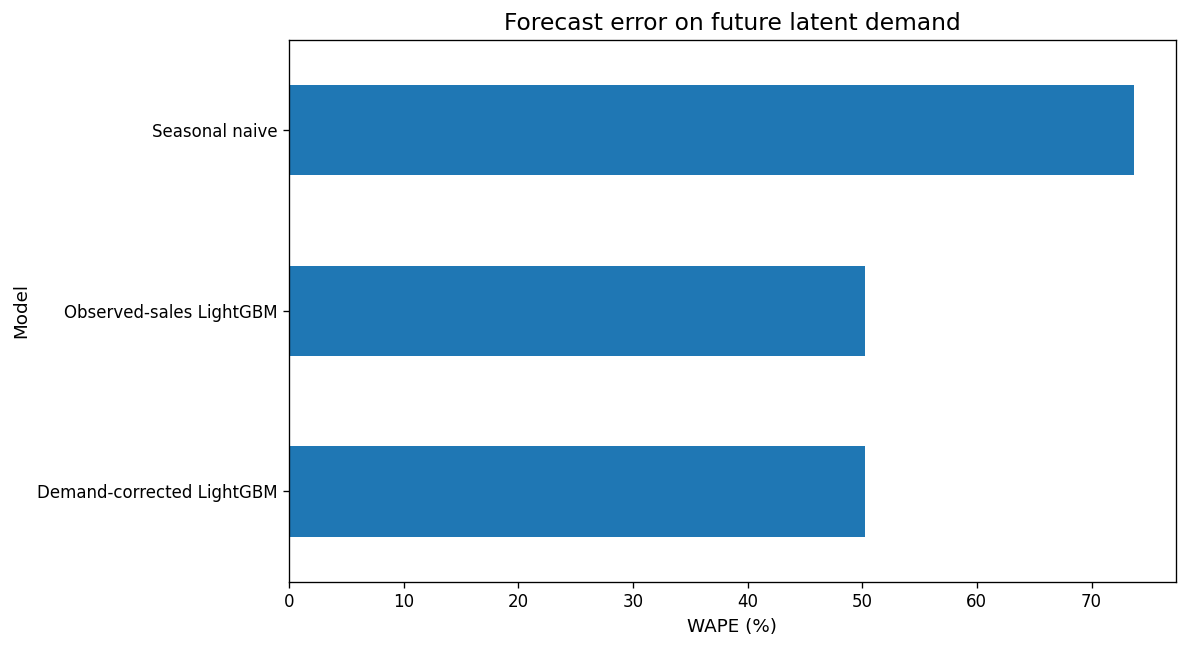

In [11]:
# Visual 4: forecast model WAPE
plot_metrics = metrics.sort_values('WAPE', ascending=True).set_index('Model')['WAPE'] * 100
plt.figure()
plot_metrics.plot(kind='barh')
plt.title('Forecast error on future latent demand')
plt.xlabel('WAPE (%)')
plt.ylabel('Model')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_forecast_wape.png', bbox_inches='tight')
plt.show()

### Interpretation

The global model should materially outperform the one-week seasonal baseline because it pools information across products and stores while using price, promotion, calendar, weather and recent-demand signals. The demand-corrected model is expected to reduce negative bias, even when the simple proxy yields only a modest error improvement. This distinction matters operationally: reducing under-forecasting can prevent repeated stockouts even when headline accuracy changes little.

In [12]:
# Probabilistic forecasts
quantile_models = {}
quantile_predictions = {}
for alpha in [0.05, 0.50, 0.90, 0.95]:
    model = LGBMRegressor(objective='quantile', alpha=alpha, **lgb_params)
    model.fit(train[FEATURES], train['demand_proxy'])
    quantile_models[alpha] = model
    quantile_predictions[alpha] = np.clip(model.predict(test[FEATURES]), 0, None)

predictions['q05'] = quantile_predictions[0.05]
predictions['q50'] = quantile_predictions[0.50]
predictions['q90'] = quantile_predictions[0.90]
predictions['q95'] = quantile_predictions[0.95]

coverage_90 = np.mean(
    (test['latent_demand'].to_numpy() >= predictions['q05']) &
    (test['latent_demand'].to_numpy() <= predictions['q95'])
)
mean_interval_width = np.mean(predictions['q95'] - predictions['q05'])
print(f'Empirical 90% interval coverage: {coverage_90:.1%}')
print(f'Mean 90% interval width: {mean_interval_width:.2f} units')

Empirical 90% interval coverage: 93.8%
Mean 90% interval width: 31.30 units


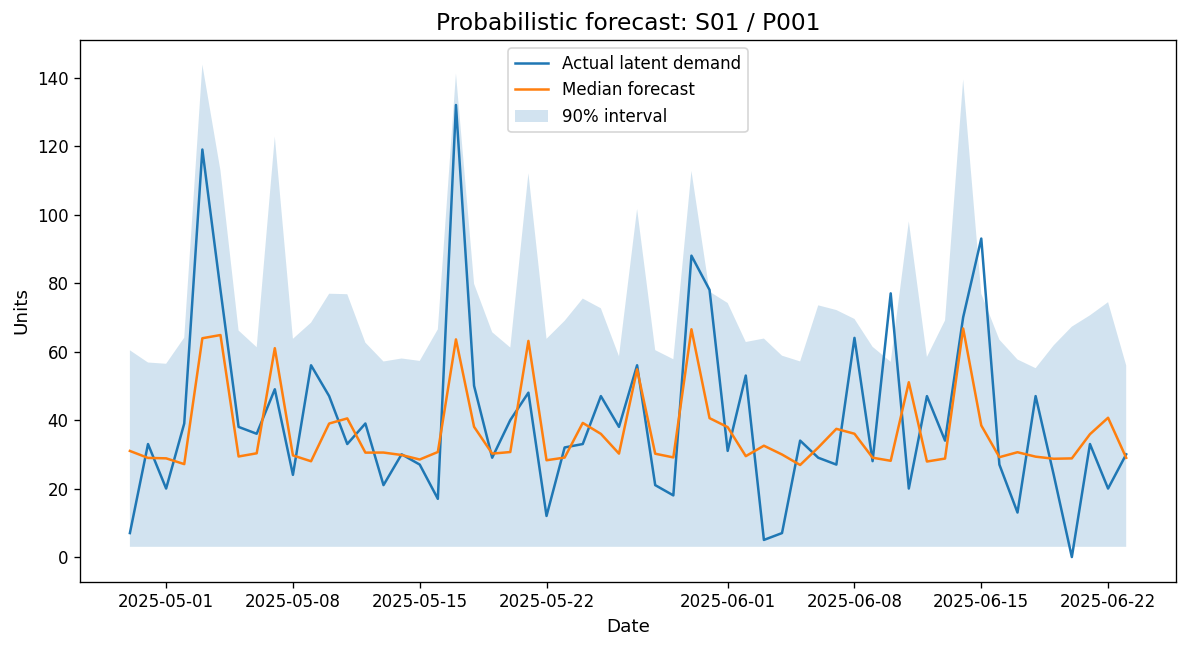

In [13]:
# Visual 5: one product-store forecast with uncertainty
example_key = (
    test.groupby(['store_id', 'product_id'])['latent_demand']
    .sum().sort_values(ascending=False).index[0]
)
example = predictions.loc[
    predictions['store_id'].eq(example_key[0]) & predictions['product_id'].eq(example_key[1])
].sort_values('date')

plt.figure()
plt.plot(example['date'], example['latent_demand'], label='Actual latent demand')
plt.plot(example['date'], example['q50'], label='Median forecast')
plt.fill_between(example['date'], example['q05'], example['q95'], alpha=0.20, label='90% interval')
plt.title(f'Probabilistic forecast: {example_key[0]} / {example_key[1]}')
plt.xlabel('Date')
plt.ylabel('Units')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_probabilistic_forecast.png', bbox_inches='tight')
plt.show()

In [14]:
# Explainability with permutation importance on a reproducible test sample
importance_sample = test.sample(min(1200, len(test)), random_state=SEED)
importance_result = permutation_importance(
    corrected_model,
    importance_sample[FEATURES],
    importance_sample['latent_demand'],
    scoring='neg_mean_absolute_error',
    n_repeats=2,
    random_state=SEED,
    n_jobs=1,
)
importance = (
    pd.DataFrame({'feature': FEATURES, 'importance': importance_result.importances_mean})
    .sort_values('importance', ascending=False)
)
display(importance.head(15))

,feature,importance
29,roll_mean_28,2.843
2,discount,0.652
3,promo,0.111
11,dow,0.059
21,category_code,0.042
31,roll_std_28,0.040
9,health_score,0.030
19,store_format_code,0.020
1,price,0.019
28,roll_mean_7,0.017


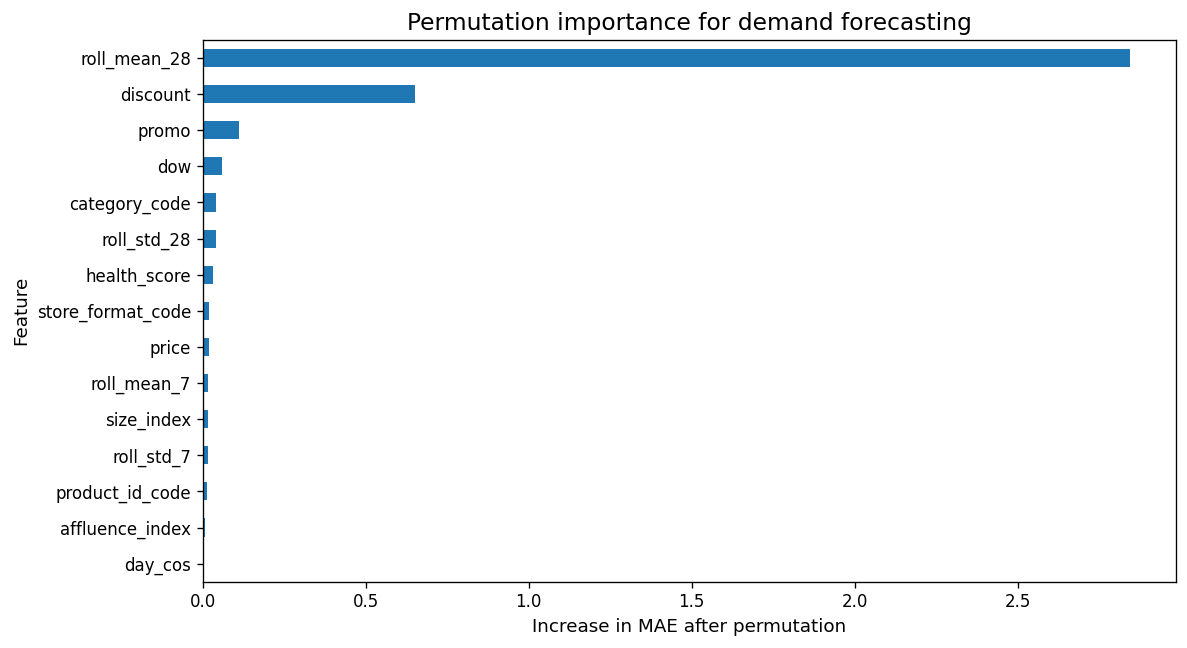

In [15]:
# Visual 6: top model drivers
plt.figure()
importance.head(15).sort_values('importance').set_index('feature')['importance'].plot(kind='barh')
plt.title('Permutation importance for demand forecasting')
plt.xlabel('Increase in MAE after permutation')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_permutation_importance.png', bbox_inches='tight')
plt.show()

In [16]:
# Segment diagnostics
segment_rows = []
for segment_name, group in predictions.groupby('store_format'):
    segment_rows.append({
        'store_format': segment_name,
        'n': len(group),
        'WAPE': np.abs(group['latent_demand'] - group['corrected_ml']).sum() / group['latent_demand'].sum(),
        'Bias': (group['corrected_ml'] - group['latent_demand']).mean(),
    })
segment_performance = pd.DataFrame(segment_rows).sort_values('WAPE')
display(segment_performance)

,store_format,n,WAPE,Bias
1,superstore,2016,0.473,-1.228
2,urban,1008,0.535,-0.861
0,convenience,1008,0.562,-0.318


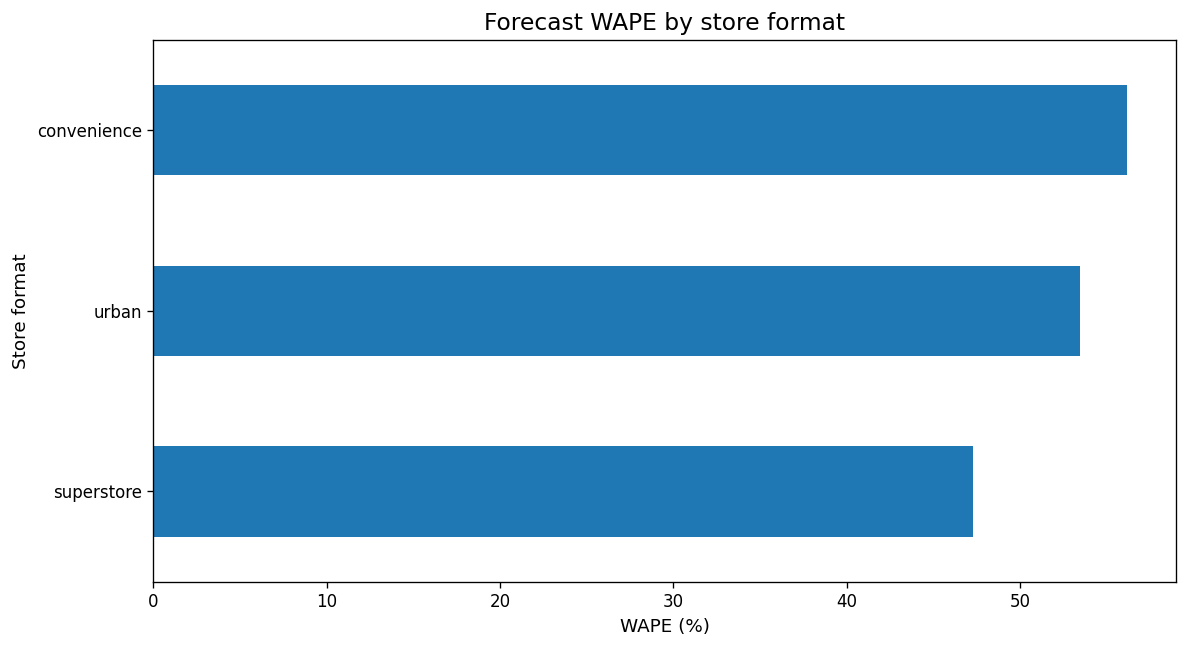

In [17]:
# Visual 7: forecast error by store format
plt.figure()
segment_performance.set_index('store_format')['WAPE'].mul(100).sort_values().plot(kind='barh')
plt.title('Forecast WAPE by store format')
plt.xlabel('WAPE (%)')
plt.ylabel('Store format')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_segment_wape.png', bbox_inches='tight')
plt.show()

## 4. Stockout risk prediction

The classifier uses demand signals, store/product attributes and the known available stock before demand is realised. Because stockouts are imbalanced, evaluation includes ROC-AUC, average precision, Brier score, threshold-specific precision/recall, and calibration.

In [18]:
STOCKOUT_FEATURES = FEATURES + ['available_stock']
stockout_model = LGBMClassifier(
    n_estimators=110,
    learning_rate=0.05,
    num_leaves=20,
    class_weight='balanced',
    random_state=SEED,
    verbosity=-1,
    n_jobs=1,
)
stockout_model.fit(train[STOCKOUT_FEATURES], train['stockout'])
stockout_probability = stockout_model.predict_proba(test[STOCKOUT_FEATURES])[:, 1]

stockout_metrics = {
    'ROC-AUC': roc_auc_score(test['stockout'], stockout_probability),
    'Average precision': average_precision_score(test['stockout'], stockout_probability),
    'Brier score': brier_score_loss(test['stockout'], stockout_probability),
    'Prevalence': test['stockout'].mean(),
}
display(pd.DataFrame([stockout_metrics]))

precision, recall, thresholds = precision_recall_curve(test['stockout'], stockout_probability)
f2 = (5 * precision * recall) / np.maximum(4 * precision + recall, 1e-12)
best_index = int(np.nanargmax(f2[:-1]))
best_threshold = thresholds[best_index]
flag = stockout_probability >= best_threshold
cm = confusion_matrix(test['stockout'], flag)
print(f'Operational threshold selected by F2: {best_threshold:.3f}')
print('Confusion matrix [[TN, FP], [FN, TP]]:')
print(cm)

,ROC-AUC,Average precision,Brier score,Prevalence
0,0.747,0.285,0.186,0.084


Operational threshold selected by F2: 0.451
Confusion matrix [[TN, FP], [FN, TP]]:
[[2569 1125]
 [ 109  229]]


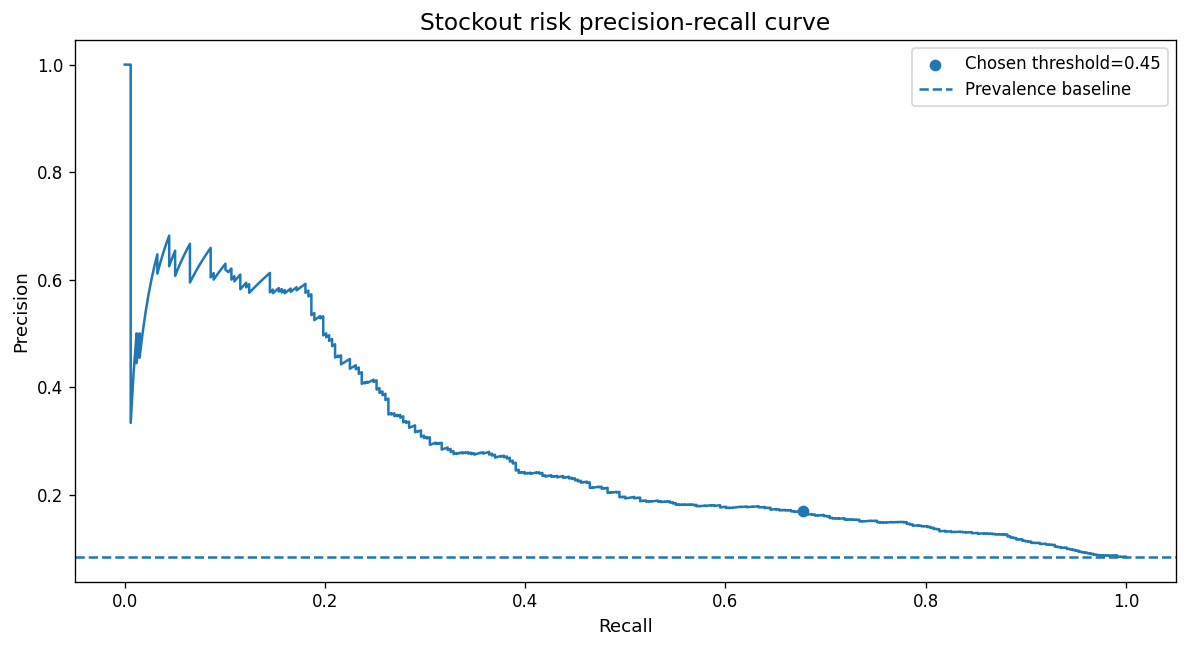

In [19]:
# Visual 8: precision-recall curve
plt.figure()
plt.plot(recall, precision)
plt.scatter(recall[best_index], precision[best_index], label=f'Chosen threshold={best_threshold:.2f}')
plt.axhline(test['stockout'].mean(), linestyle='--', label='Prevalence baseline')
plt.title('Stockout risk precision-recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '08_stockout_pr_curve.png', bbox_inches='tight')
plt.show()

In [20]:
# Calibration table
prob_true, prob_pred = calibration_curve(test['stockout'], stockout_probability, n_bins=10, strategy='quantile')
calibration = pd.DataFrame({'Predicted risk': prob_pred, 'Observed rate': prob_true})
display(calibration)

,Predicted risk,Observed rate
0,0.194,0.030
1,0.258,0.017
2,0.295,0.025
3,0.330,0.027
4,0.366,0.060
5,0.404,0.067
6,0.444,0.082
7,0.497,0.122
8,0.576,0.132
9,0.767,0.277


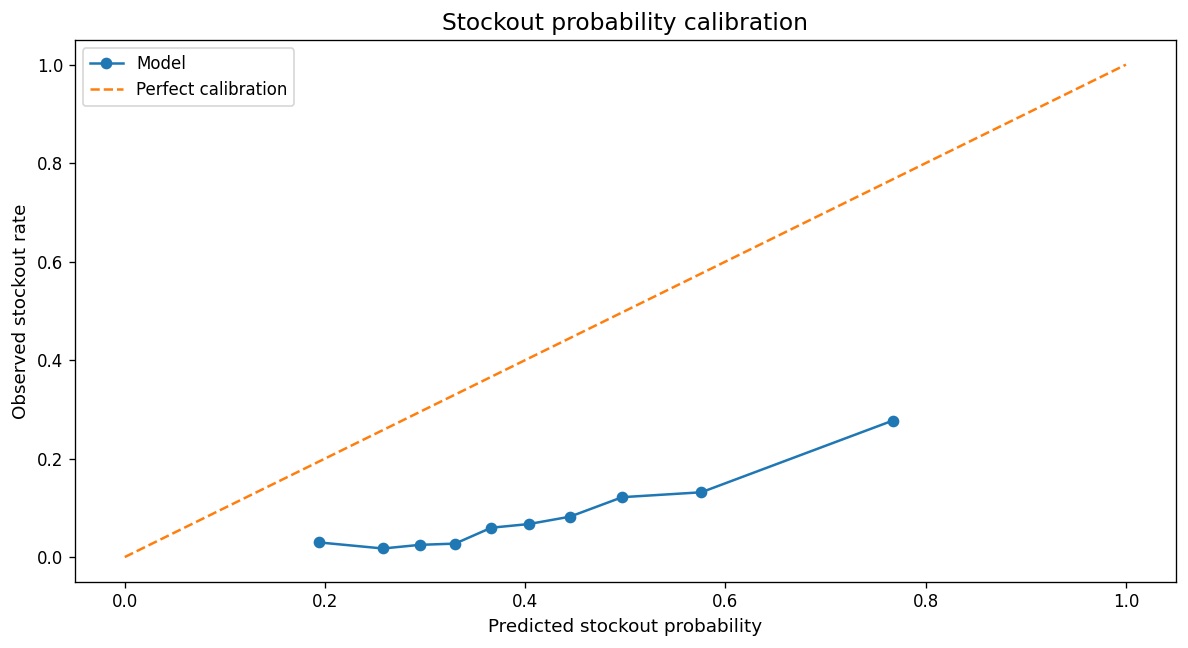

In [21]:
# Visual 9: calibration curve
plt.figure()
plt.plot(calibration['Predicted risk'], calibration['Observed rate'], marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
plt.title('Stockout probability calibration')
plt.xlabel('Predicted stockout probability')
plt.ylabel('Observed stockout rate')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '09_stockout_calibration.png', bbox_inches='tight')
plt.show()

### Operational implication

A stockout model should not be judged only by accuracy. The threshold can be tuned toward recall when the cost of missing a likely stockout is greater than the cost of investigating a false alert. Calibration is equally important because replenishment teams need meaningful probabilities, not just rankings.

## 5. Product-substitution ranking

Each simulated out-of-stock event offers four candidate products. The customer may accept one candidate or reject all substitutions. The model learns candidate acceptance from:

- price difference,
- pack-size difference,
- health-score difference,
- same brand or tier,
- personal affinity,
- prior purchase match,
- category compatibility.

The evaluation is performed at the **event level**, where the business decision is which single substitute to offer first.

In [22]:
def simulate_substitution_events(products, n_events=2500, seed=42):
    local_rng = np.random.default_rng(seed)
    records = products.to_dict('records')
    category_to_indices = {
        category: np.flatnonzero(products['category'].eq(category).to_numpy())
        for category in products['category'].unique()
    }
    adjacency = {
        'Fresh': ['Fresh', 'Bakery'],
        'Dairy': ['Dairy', 'Plant-based'],
        'Bakery': ['Bakery', 'Fresh'],
        'Plant-based': ['Plant-based', 'Dairy'],
        'Household': ['Household'],
        'Beverages': ['Beverages'],
    }
    compatible_indices = {}
    for category, allowed in adjacency.items():
        compatible_indices[category] = np.concatenate([category_to_indices[c] for c in allowed])

    candidate_rows = []
    for event_id in range(n_events):
        source_index = int(local_rng.integers(0, len(records)))
        source = records[source_index]
        pool = compatible_indices[source['category']]
        pool = pool[pool != source_index]
        candidate_indices = local_rng.choice(pool, size=4, replace=len(pool) < 4)

        utilities = []
        event_rows = []
        for rank, candidate_index in enumerate(candidate_indices):
            candidate = records[int(candidate_index)]
            relative_price_gap = abs(candidate['base_price'] - source['base_price']) / source['base_price']
            size_gap = abs(candidate['size_index'] - source['size_index'])
            health_gap = abs(candidate['health_score'] - source['health_score']) / 4
            same_brand = int(candidate['brand_id'] == source['brand_id'])
            same_tier = int(candidate['brand_tier'] == source['brand_tier'])
            same_category = int(candidate['category'] == source['category'])
            affinity = local_rng.beta(2.2, 2.0)
            past_purchase = int(local_rng.random() < (0.15 + 0.55 * affinity))

            utility = (
                -1.00
                - 2.20 * relative_price_gap
                - 1.30 * size_gap
                - 0.75 * health_gap
                + 0.90 * same_tier
                + 0.75 * same_brand
                + 0.80 * same_category
                + 1.35 * affinity
                + 1.55 * past_purchase
                + local_rng.normal(0, 0.25)
            )
            utilities.append(utility)
            event_rows.append({
                'event_id': event_id,
                'source_product': source['product_id'],
                'candidate_product': candidate['product_id'],
                'source_category': source['category'],
                'candidate_category': candidate['category'],
                'source_tier': source['brand_tier'],
                'candidate_tier': candidate['brand_tier'],
                'candidate_price': candidate['base_price'],
                'relative_price_gap': relative_price_gap,
                'size_gap': size_gap,
                'health_gap': health_gap,
                'same_brand': same_brand,
                'same_tier': same_tier,
                'same_category': same_category,
                'affinity': affinity,
                'past_purchase': past_purchase,
                'candidate_position': rank,
            })

        choice_probabilities = softmax(np.array(utilities + [0.35]))
        chosen = int(local_rng.choice(5, p=choice_probabilities))
        for candidate_index, row in enumerate(event_rows):
            row['accepted'] = int(chosen == candidate_index)
            row['event_has_acceptance'] = int(chosen < 4)
            candidate_rows.append(row)

    return pd.DataFrame(candidate_rows)

substitution = simulate_substitution_events(products, n_events=2500, seed=SEED)
print(f'Event acceptance rate: {substitution.groupby("event_id")["accepted"].max().mean():.1%}')
display(substitution.head())

Event acceptance rate: 73.9%


,event_id,source_product,candidate_product,source_category,candidate_category,source_tier,candidate_tier,candidate_price,relative_price_gap,size_gap,health_gap,same_brand,same_tier,same_category,affinity,past_purchase,candidate_position,accepted,event_has_acceptance
0,0,P002,P010,Dairy,Plant-based,standard,value,5.610,0.060,0.139,0.118,1,0,0,0.554,1,0,0,1
1,0,P002,P004,Dairy,Plant-based,standard,value,6.400,0.072,0.360,0.096,0,0,0,0.455,0,1,0,1
2,0,P002,P014,Dairy,Dairy,standard,standard,4.670,0.218,0.266,0.044,0,1,1,0.699,0,2,1,1
3,0,P002,P016,Dairy,Plant-based,standard,value,2.070,0.653,0.042,0.069,0,0,0,0.353,1,3,0,1
4,1,P007,P015,Fresh,Bakery,value,premium,1.250,0.352,0.166,0.208,1,0,0,0.829,0,0,0,0


In [23]:
SUB_FEATURES = [
    'candidate_price', 'relative_price_gap', 'size_gap', 'health_gap',
    'same_brand', 'same_tier', 'same_category', 'affinity', 'past_purchase',
    'candidate_position',
]

train_events = set(range(0, 2000))
sub_train = substitution[substitution['event_id'].isin(train_events)].copy()
sub_test = substitution[~substitution['event_id'].isin(train_events)].copy()

sub_model = LogisticRegression(
    max_iter=500,
    class_weight='balanced',
    random_state=SEED,
)
sub_model.fit(sub_train[SUB_FEATURES], sub_train['accepted'])
sub_test['accept_probability'] = sub_model.predict_proba(sub_test[SUB_FEATURES])[:, 1]

# One recommendation per event
model_choice = sub_test.loc[sub_test.groupby('event_id')['accept_probability'].idxmax()]
closest_price_choice = sub_test.loc[sub_test.groupby('event_id')['relative_price_gap'].idxmin()]
past_purchase_choice = sub_test.sort_values(
    ['event_id', 'past_purchase', 'affinity', 'relative_price_gap'],
    ascending=[True, False, False, True]
).groupby('event_id').head(1)

substitution_results = pd.DataFrame({
    'Policy': ['ML attribute-aware', 'Closest price', 'Purchase-history heuristic'],
    'Top-1 acceptance': [
        model_choice['accepted'].mean(),
        closest_price_choice['accepted'].mean(),
        past_purchase_choice['accepted'].mean(),
    ],
    'Mean retained revenue': [
        (model_choice['accepted'] * model_choice['candidate_price']).mean(),
        (closest_price_choice['accepted'] * closest_price_choice['candidate_price']).mean(),
        (past_purchase_choice['accepted'] * past_purchase_choice['candidate_price']).mean(),
    ],
})
display(substitution_results)

,Policy,Top-1 acceptance,Mean retained revenue
0,ML attribute-aware,0.404,1.927
1,Closest price,0.270,1.341
2,Purchase-history heuristic,0.322,1.511


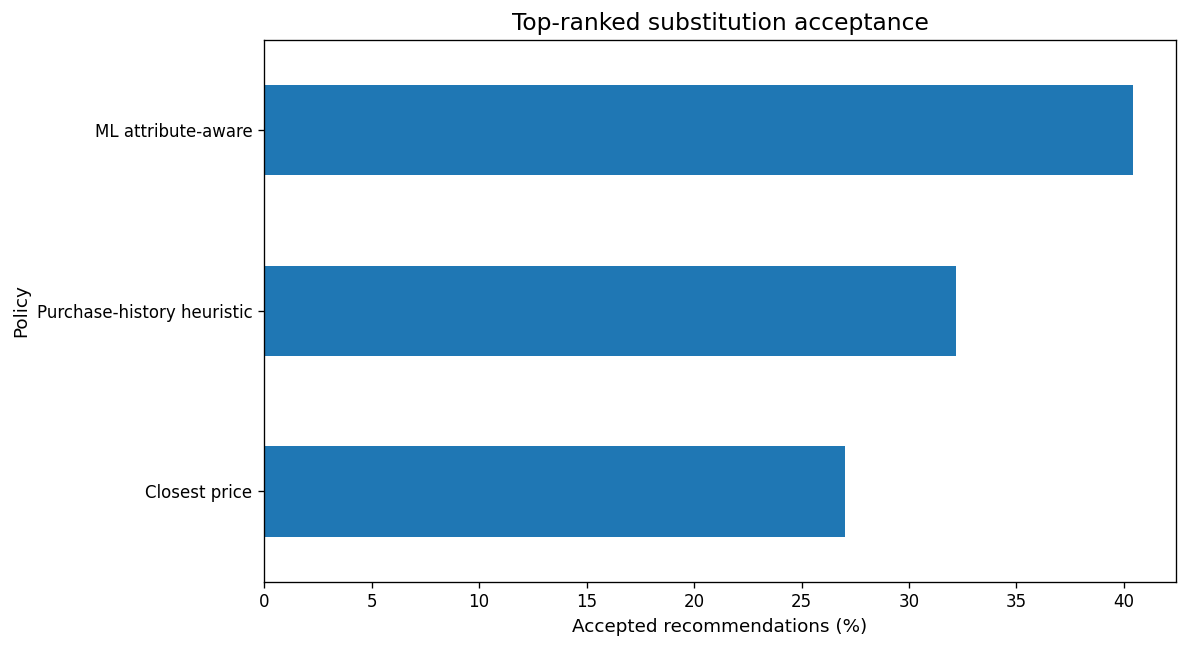

In [24]:
# Visual 10: substitution policy comparison
plt.figure()
substitution_results.set_index('Policy')['Top-1 acceptance'].mul(100).sort_values().plot(kind='barh')
plt.title('Top-ranked substitution acceptance')
plt.xlabel('Accepted recommendations (%)')
plt.ylabel('Policy')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '10_substitution_acceptance.png', bbox_inches='tight')
plt.show()

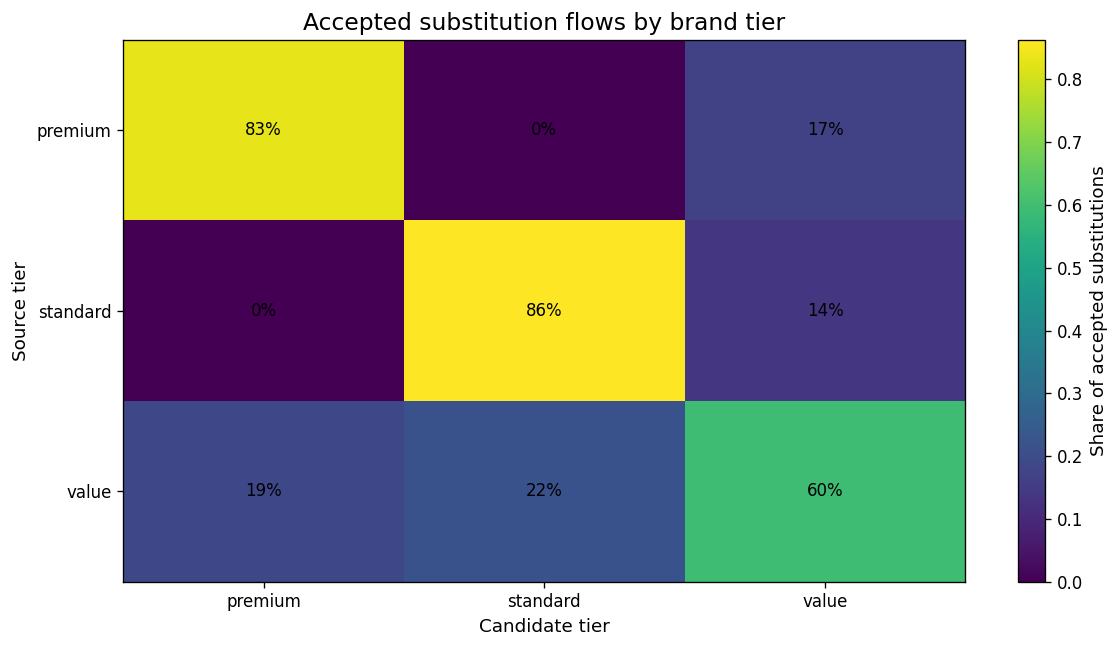

In [25]:
# Visual 11: source-tier to accepted substitute-tier matrix
accepted_pairs = substitution[substitution['accepted'].eq(1)]
tier_matrix = pd.crosstab(
    accepted_pairs['source_tier'],
    accepted_pairs['candidate_tier'],
    normalize='index'
)
plt.figure()
plt.imshow(tier_matrix.to_numpy(), aspect='auto')
plt.xticks(range(len(tier_matrix.columns)), tier_matrix.columns)
plt.yticks(range(len(tier_matrix.index)), tier_matrix.index)
plt.colorbar(label='Share of accepted substitutions')
plt.title('Accepted substitution flows by brand tier')
plt.xlabel('Candidate tier')
plt.ylabel('Source tier')
for i in range(tier_matrix.shape[0]):
    for j in range(tier_matrix.shape[1]):
        plt.text(j, i, f'{tier_matrix.iloc[i, j]:.0%}', ha='center', va='center')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '11_substitution_tier_matrix.png', bbox_inches='tight')
plt.show()

## 6. Promotion impact evaluation

A difference-in-differences model compares Plant-based products with control categories around January 2025. Store and week fixed effects absorb persistent store differences and common weekly shocks. The simulated 57% campaign multiplier is known, so the analysis can be checked for recovery of the direction and approximate magnitude.

In [26]:
window = retail.loc[retail['date'].between('2024-12-01', '2025-02-28')].copy()
window['week'] = window['date'].dt.to_period('W').astype(str)
weekly = (
    window.groupby(['store_id', 'category', 'week'], as_index=False)['units_sold']
    .sum()
)
weekly = weekly[weekly['category'].isin(['Plant-based', 'Household', 'Dairy'])].copy()
weekly['treated'] = weekly['category'].eq('Plant-based').astype(int)
weekly['post'] = weekly['week'].str.contains('2025-01').astype(int)
weekly['log_units'] = np.log1p(weekly['units_sold'])

did_model = smf.ols(
    'log_units ~ treated * post + C(store_id) + C(week)',
    data=weekly,
).fit(cov_type='HC3')

interaction = did_model.params['treated:post']
estimated_uplift = np.expm1(interaction)
print(f'Difference-in-differences estimated campaign uplift: {estimated_uplift:.1%}')
print(f'Robust p-value: {did_model.pvalues["treated:post"]:.3g}')
display(pd.DataFrame({
    'Coefficient': did_model.params,
    'Robust SE': did_model.bse,
    'p-value': did_model.pvalues,
}).loc[['treated', 'post', 'treated:post']])

Difference-in-differences estimated campaign uplift: 47.8%
Robust p-value: 0.082


,Coefficient,Robust SE,p-value
treated,-0.184,0.134,0.171
post,1.584,0.269,0.000
treated:post,0.391,0.225,0.082


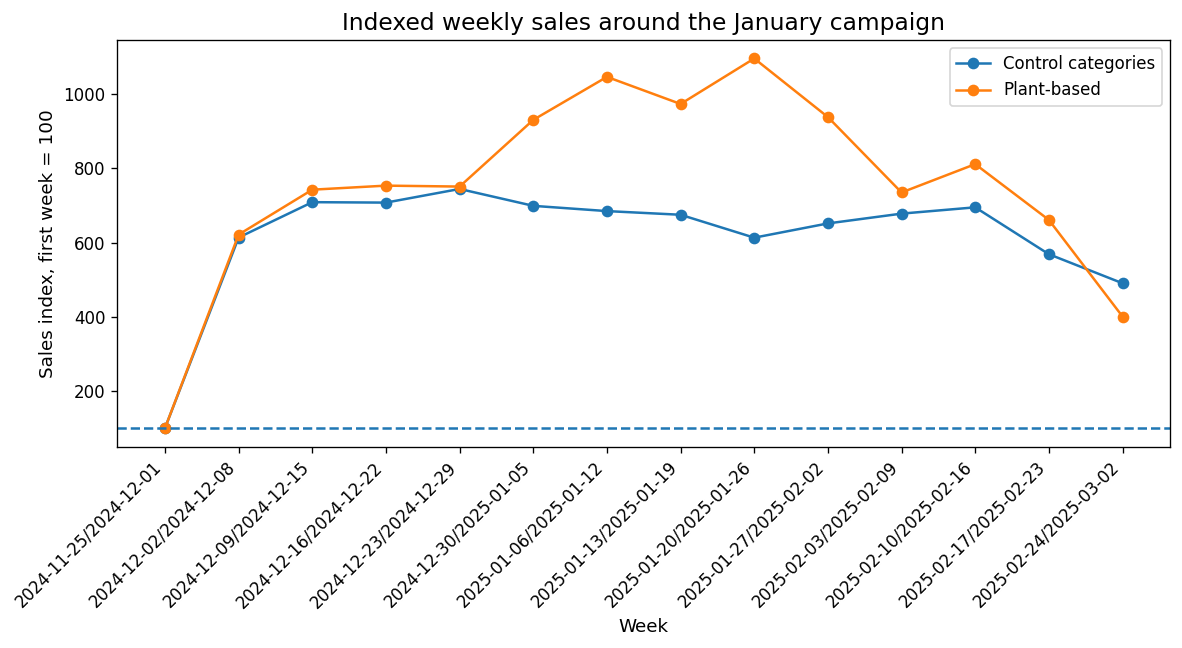

In [27]:
# Visual 12: indexed weekly campaign trend
indexed = weekly.groupby(['week', 'treated'])['units_sold'].mean().unstack()
indexed = indexed.div(indexed.iloc[0], axis=1) * 100
indexed.columns = ['Control categories', 'Plant-based']
plt.figure()
for column in indexed.columns:
    plt.plot(indexed.index, indexed[column], marker='o', label=column)
plt.axhline(100, linestyle='--')
plt.title('Indexed weekly sales around the January campaign')
plt.xlabel('Week')
plt.ylabel('Sales index, first week = 100')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '12_campaign_did.png', bbox_inches='tight')
plt.show()

### Interpretation

The promotion analysis demonstrates how a retail data scientist can move beyond correlation. A campaign-versus-control design, fixed effects and robust uncertainty provide a clearer estimate of incremental sales. In production, the same framework should be strengthened with pre-trend checks, matched controls, synthetic controls, causal forests or randomised experiments when feasible.

## 7. Forecast-to-inventory decision optimisation

Forecast accuracy is not the final objective. The decision layer compares:

- a **seasonal-naive stock policy**, based on last week's sales and a simple safety buffer;
- a **probabilistic ML policy**, using the 90th demand quantile.

The evaluation uses service level, lost units, waste units, retained margin and total decision cost. Perishable categories receive a higher spoilage penalty.

In [28]:
inventory = test[[
    'latent_demand', 'regular_price', 'unit_cost', 'perishable',
    'category', 'store_id', 'product_id'
]].copy()
inventory['naive_stock'] = np.ceil(
    np.maximum(test['lag_7'].to_numpy(), 0) + 0.35 * np.sqrt(np.maximum(test['lag_7'].to_numpy(), 0) + 1)
)
inventory['ml_stock'] = np.ceil(predictions['q90'].to_numpy())


def evaluate_inventory_policy(frame, stock_col, policy_name):
    demand = frame['latent_demand'].to_numpy()
    stock = frame[stock_col].to_numpy()
    fulfilled = np.minimum(demand, stock)
    lost = np.maximum(demand - stock, 0)
    leftover = np.maximum(stock - demand, 0)
    spoilage_fraction = np.where(frame['perishable'].to_numpy().eq(1) if hasattr(frame['perishable'].to_numpy(), 'eq') else frame['perishable'].to_numpy() == 1, 0.40, 0.05)
    waste = leftover * spoilage_fraction
    margin_per_unit = frame['regular_price'].to_numpy() - frame['unit_cost'].to_numpy()
    lost_margin = lost * margin_per_unit
    waste_cost = waste * frame['unit_cost'].to_numpy()
    holding_cost = (leftover - waste) * frame['unit_cost'].to_numpy() * 0.03
    total_cost = lost_margin + waste_cost + holding_cost
    retained_margin = fulfilled * margin_per_unit - waste_cost - holding_cost

    return {
        'Policy': policy_name,
        'Service level': fulfilled.sum() / max(demand.sum(), 1),
        'Lost units': lost.sum(),
        'Waste units': waste.sum(),
        'Total decision cost': total_cost.sum(),
        'Retained margin proxy': retained_margin.sum(),
        'Average stock': stock.mean(),
    }

inventory_results = pd.DataFrame([
    evaluate_inventory_policy(inventory, 'naive_stock', 'Seasonal-naive policy'),
    evaluate_inventory_policy(inventory, 'ml_stock', 'Probabilistic ML policy'),
])
display(inventory_results)

,Policy,Service level,Lost units,Waste units,Total decision cost,Retained margin proxy,Average stock
0,Seasonal-naive policy,0.667,"19,981.000","8,024.750","63,084.133","50,532.434",16.217
1,Probabilistic ML policy,0.958,"2,515.000","17,079.000","58,712.151","54,904.416",27.810


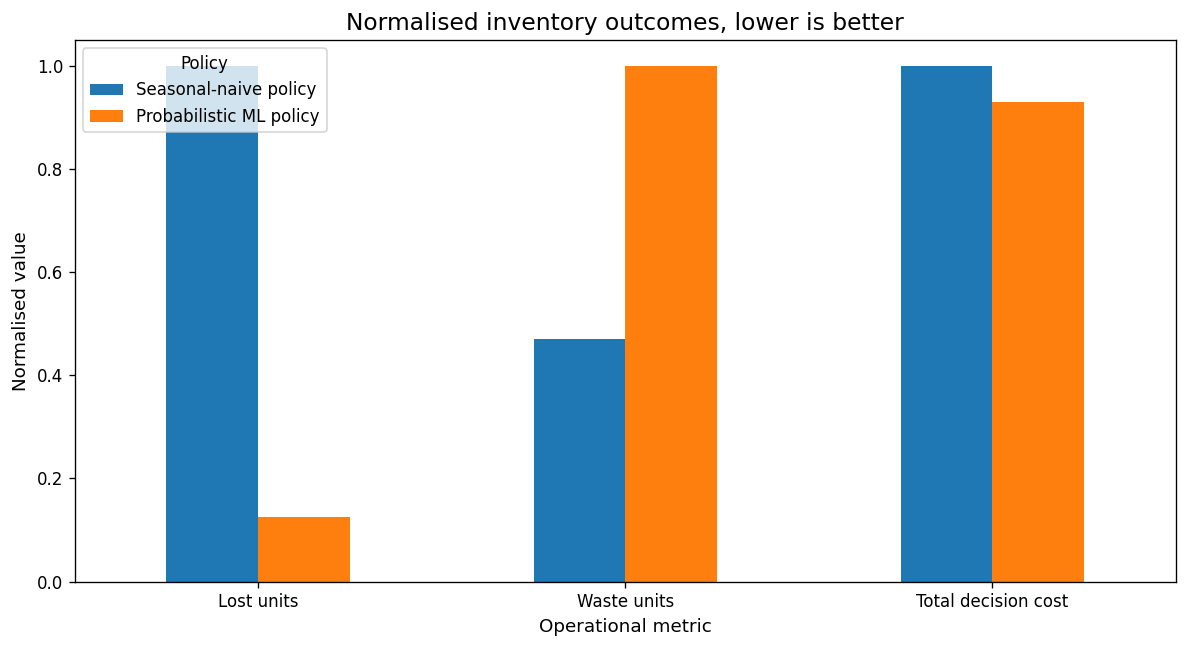

In [29]:
# Visual 13: normalised inventory decision outcomes
inventory_plot = inventory_results.set_index('Policy')[
    ['Lost units', 'Waste units', 'Total decision cost']
].copy()
inventory_plot = inventory_plot.div(inventory_plot.max(axis=0), axis=1)
plt.figure()
inventory_plot.T.plot(kind='bar', ax=plt.gca())
plt.title('Normalised inventory outcomes, lower is better')
plt.xlabel('Operational metric')
plt.ylabel('Normalised value')
plt.xticks(rotation=0)
plt.legend(title='Policy')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '13_inventory_outcomes.png', bbox_inches='tight')
plt.show()

## 8. Consolidated business interpretation

The notebook is intentionally decision-centred. A strong production version would connect each model to an action, owner, cost function, monitoring rule and experiment:

| Analytical layer | Decision supported | Main implication |
|---|---|---|
| Global demand forecast | Replenishment, labour, capacity and availability planning | Pooling information across products and stores can outperform isolated series models |
| Latent-demand correction | True demand estimation | Sales are not equal to demand when stockouts censor observations |
| Quantile forecasting | Safety stock and service-level choice | Prediction intervals allow explicit cost-risk trade-offs |
| Stockout classifier | Alert prioritisation | Thresholds should reflect the relative cost of missed stockouts and false alerts |
| Substitution ranking | Online fulfilment and customer retention | Purchase history plus product attributes can beat one-dimensional price matching |
| Difference-in-differences | Incremental campaign measurement | Causal design is needed before attributing sales changes to promotions |
| Segment diagnostics | Responsible deployment and operational tailoring | Performance should be monitored by format, category, geography and customer segment |
| Inventory optimisation | Margin, availability and waste | The best model is the one that improves the operational objective, not merely MAE |

In [30]:
# Consolidated scorecard
best_forecast = metrics.iloc[0]
naive_wape = metrics.loc[metrics['Model'].eq('Seasonal naive'), 'WAPE'].iloc[0]
best_wape = best_forecast['WAPE']
sub_ml = substitution_results.loc[substitution_results['Policy'].eq('ML attribute-aware')].iloc[0]
sub_baseline = substitution_results.loc[substitution_results['Policy'].eq('Closest price')].iloc[0]
inv_naive = inventory_results.loc[inventory_results['Policy'].eq('Seasonal-naive policy')].iloc[0]
inv_ml = inventory_results.loc[inventory_results['Policy'].eq('Probabilistic ML policy')].iloc[0]

scorecard = pd.DataFrame({
    'Outcome': [
        'Forecast WAPE reduction vs seasonal naive',
        'Forecast bias of demand-corrected model',
        '90% prediction interval coverage',
        'Stockout ROC-AUC',
        'Substitution top-1 acceptance gain',
        'Estimated campaign uplift',
        'Inventory decision-cost reduction',
        'Inventory service-level change',
    ],
    'Value': [
        (naive_wape - best_wape) / naive_wape,
        metrics.loc[metrics['Model'].eq('Demand-corrected LightGBM'), 'Bias'].iloc[0],
        coverage_90,
        stockout_metrics['ROC-AUC'],
        sub_ml['Top-1 acceptance'] - sub_baseline['Top-1 acceptance'],
        estimated_uplift,
        (inv_naive['Total decision cost'] - inv_ml['Total decision cost']) / inv_naive['Total decision cost'],
        inv_ml['Service level'] - inv_naive['Service level'],
    ],
})
display(scorecard)

,Outcome,Value
0,Forecast WAPE reduction vs seasonal naive,0.318
1,Forecast bias of demand-corrected model,-0.909
2,90% prediction interval coverage,0.938
3,Stockout ROC-AUC,0.747
4,Substitution top-1 acceptance gain,0.134
5,Estimated campaign uplift,0.478
6,Inventory decision-cost reduction,0.069
7,Inventory service-level change,0.292


In [31]:
# Save reusable outputs
retail.to_csv(OUTPUT_DIR / 'synthetic_retail_panel.csv', index=False)
metrics.to_csv(OUTPUT_DIR / 'forecast_metrics.csv', index=False)
segment_performance.to_csv(OUTPUT_DIR / 'segment_performance.csv', index=False)
substitution_results.to_csv(OUTPUT_DIR / 'substitution_policy_results.csv', index=False)
inventory_results.to_csv(OUTPUT_DIR / 'inventory_policy_results.csv', index=False)
scorecard.to_csv(OUTPUT_DIR / 'executive_scorecard.csv', index=False)

metadata = {
    'seed': SEED,
    'n_rows': int(len(retail)),
    'n_stores': int(N_STORES),
    'n_products': int(N_PRODUCTS),
    'date_start': str(DATES.min().date()),
    'date_end': str(DATES.max().date()),
    'test_cutoff': str(cutoff.date()),
}
(OUTPUT_DIR / 'simulation_metadata.json').write_text(json.dumps(metadata, indent=2))
print('Saved files:')
for path in sorted(OUTPUT_DIR.iterdir()):
    print(' -', path.name)

Saved files:
 - 01_daily_demand.png
 - 02_stockout_by_category.png
 - 03_promotion_multiplier.png
 - 04_forecast_wape.png
 - 05_probabilistic_forecast.png
 - 06_permutation_importance.png
 - 07_segment_wape.png
 - 08_stockout_pr_curve.png
 - 09_stockout_calibration.png
 - 10_substitution_acceptance.png
 - 11_substitution_tier_matrix.png
 - 12_campaign_did.png
 - 13_inventory_outcomes.png
 - executive_scorecard.csv
 - forecast_metrics.csv
 - inventory_policy_results.csv
 - segment_performance.csv
 - simulation_metadata.json
 - substitution_policy_results.csv
 - synthetic_retail_panel.csv


## 9. Limitations and production roadmap

1. **Synthetic external validity:** benchmarked ranges improve realism but do not replace retailer-specific distributions, operational constraints or customer behaviour.
2. **Censored-demand recovery:** the proxy is deliberately simple. Production work should use inventory-event timestamps, replenishment data, causal censoring models, state-space models or EM-based demand reconstruction.
3. **Forecast validation:** one chronological holdout is transparent but insufficient. Add rolling-origin backtests, disruption-specific tests and hierarchical weighted metrics such as WRMSSE.
4. **Promotion causality:** fixed-effects difference-in-differences is a starting point. Validate parallel trends, interference, cannibalisation, stockpiling and post-promotion dips.
5. **Substitution:** the candidate-choice process is simulated. Real systems should learn from acceptance, rejection, refunds, complaints and long-term customer value.
6. **Inventory constraints:** lead times, supplier minimums, shelf capacity, labour, case packs, freshness and multi-echelon constraints should be added.
7. **MLOps:** implement feature stores, model registry, versioned training data, drift monitoring, calibration monitoring, champion-challenger evaluation and rollback criteria.
8. **Responsible AI:** audit segment performance, explainability, customer welfare, healthy-choice impacts, supplier fairness and unintended promotion effects.

### Recommended next production iteration

Build a unified product-store-day feature table, establish seasonal-naive and operational baselines, run rolling backtests, recover censored demand, train global point and quantile models, calibrate stockout probabilities, deploy a shadow decision service, and evaluate incremental business value through controlled experiments.

## References

1. Makridakis S, Spiliotis E, Assimakopoulos V. M5 accuracy competition: Results, findings, and conclusions. *International Journal of Forecasting*. 2022;38(4):1346–1364. https://doi.org/10.1016/j.ijforecast.2021.11.013
2. Makridakis S, Spiliotis E, Assimakopoulos V. The M5 competition: Background, organization, and implementation. *International Journal of Forecasting*. 2022;38(4):1325–1336. https://doi.org/10.1016/j.ijforecast.2021.07.007
3. Ziel F. M5 competition uncertainty: Overdispersion, distributional forecasting, GAMLSS, and beyond. *International Journal of Forecasting*. 2022;38(4):1546–1554. https://doi.org/10.1016/j.ijforecast.2021.09.008
4. Fildes R, Ma S, Kolassa S. Post-script—Retail forecasting: Research and practice. *International Journal of Forecasting*. 2022. PMID: 36217499. https://doi.org/10.1016/j.ijforecast.2021.09.012
5. Powell LM, Kumanyika SK, Isgor Z, Rimkus L, Zenk SN, Chaloupka FJ. Price promotions for food and beverage products in a nationwide sample of food stores. *Preventive Medicine*. 2016;86:106–113. PMID: 26827618. https://doi.org/10.1016/j.ypmed.2016.01.011
6. Rosin M, Young L, Jiang Y, Vandevijvere S, Waterlander W, Mackay S, Ni Mhurchu C. Product promotional strategies in supermarkets and their effects on sales: A case study of breakfast cereals and drinks in New Zealand. *Nutrition & Dietetics*. 2023;80(5):463–471. PMID: 36843241. https://doi.org/10.1111/1747-0080.12800
7. Trewern J, Chenoweth J, Christie I, Halevy S. Does promoting plant-based products in Veganuary lead to increased sales, and a reduction in meat sales? A natural experiment in a supermarket setting. *Public Health Nutrition*. 2022;25(11):3204–3214. PMID: 36073024. https://doi.org/10.1017/S1368980022001914
8. Luick M, Bandy L, Piernas C, Jebb SA, Pechey R. Do promotions of healthier or more sustainable foods increase sales? Findings from three natural experiments in UK supermarkets. *BMC Public Health*. 2024;24:1658. PMID: 38907224. https://doi.org/10.1186/s12889-024-19080-x
9. Vasconcellos LHR, Sampaio M. The stockouts study: An examination of the extent and the causes in the São Paulo supermarket sector. *Brazilian Administration Review*. 2009;6(3):263–279. https://doi.org/10.1590/S1807-76922009000300007
10. Anupindi R, Dada M, Gupta S. Estimation of consumer demand with stock-out based substitution: An application to vending machine products. *Marketing Science*. 1998;17(4):406–423. https://doi.org/10.1287/mksc.17.4.406
11. Hoang D, Breugelmans E. “Sorry, the product you ordered is out of stock”: Effects of substitution policy in online grocery retailing. *Journal of Retailing*. 2023;99(1):26–45. https://doi.org/10.1016/j.jretai.2022.06.006